# Bifurcations — When the Rules Change

stabiliy & potential taught us how a system **behaves** given a fixed rule: we learned to find fixed points, classify their stability, and interpret potential wells.

this one here asks a deeper question: **what happens when the rules themselves change?**

In a dynamical system $\dot{x} = f(x; r)$, the parameter $r$ controls the *shape* of the vector field. As $r$ varies smoothly, the fixed points usually move smoothly too — until they don't. At certain critical values of $r$, fixed points can:

- **appear** out of thin air,
- **disappear** (annihilate each other),
- **swap stability** (an attractor becomes a repeller and vice versa),
- **split** into multiple new branches.

These qualitative changes in the phase portrait are called **bifurcations**.

---

## The Causal AI Connection: Learning as Structural Change

In Causal AI, this is the **mathematics of learning**. Every time you update the weights $w$ of a neural network via gradient descent, you are changing the parameters of the differential equation that governs the network's dynamics.

A **bifurcation** occurs when a tiny change in a weight suddenly creates a new fixed point (a new memory) or destroys an old one. This chapter gives us the precise vocabulary and tools to understand these critical transitions.

We will cover three fundamental types:

| Bifurcation Type | What Happens | AI Analogy |
|---|---|---|
| **Saddle-Node** | Fixed points are created or destroyed | A new memory is born / forgotten |
| **Transcritical** | Fixed points exchange stability | The dominant decision flips |
| **Pitchfork** | A fixed point splits into branches | Symmetry breaking in neurons |

# Saddle-Node Bifurcation

## The Prototypical Example

The **saddle-node bifurcation** is the most fundamental mechanism by which fixed points are *created* and *destroyed*.

Consider the normal form:

$$\dot{x} = r - x^2$$

where $r$ is a tunable parameter (think of it as a weight in a neural network).

---

## Fixed Point Analysis

Setting $\dot{x} = 0$:

$$r - x^2 = 0 \quad \Longrightarrow \quad x^* = \pm\sqrt{r}$$

This equation has solutions **only when** $r \geq 0$.

| Parameter $r$ | Fixed Points | Stability |
|---|---|---|
| $r < 0$ | **None** — no fixed points exist | All trajectories sweep to $-\infty$ |
| $r = 0$ | **One** at $x^* = 0$ | Half-stable (stable from above, unstable from below) |
| $r > 0$ | **Two**: $x^* = +\sqrt{r}$ and $x^* = -\sqrt{r}$ | $+\sqrt{r}$ is **stable**, $-\sqrt{r}$ is **unstable** |

## Stability Derivation

The derivative of $f(x) = r - x^2$ is:

$$f'(x) = -2x$$

- At $x^* = +\sqrt{r}$: $f'(+\sqrt{r}) = -2\sqrt{r} < 0$ → **stable** ✓
- At $x^* = -\sqrt{r}$: $f'(-\sqrt{r}) = +2\sqrt{r} > 0$ → **unstable** ✗

The key insight: as $r$ decreases through $0$, the two fixed points **collide** and **annihilate** each other. This is sometimes called a "blue-sky" bifurcation — the fixed points vanish into thin air.

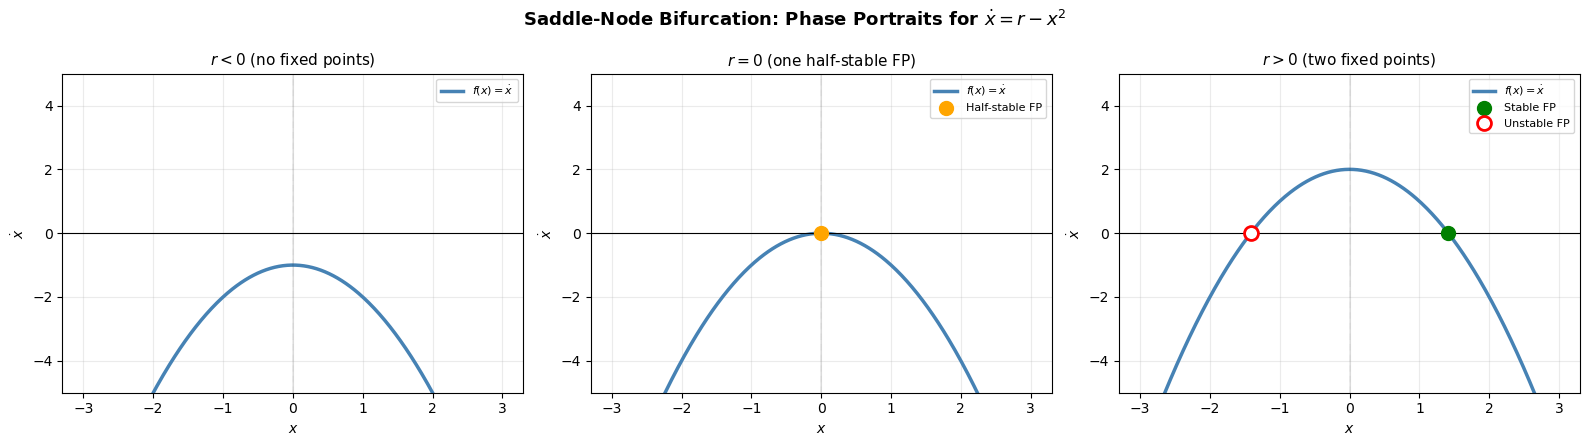


Key observations:
  • r < 0 : No fixed points. The flow drags all states to the left (ẋ < 0 everywhere).
  • r = 0 : One half-stable fixed point at x* = 0. Stable from the right, unstable from the left.
  • r > 0 : Two fixed points appear — a stable attractor and an unstable repeller.
  • The transition at r = 0 is the saddle-node bifurcation.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Saddle-Node Bifurcation: Phase Portraits for ẋ = r − x²
# ─────────────────────────────────────────────────────────────────

def f_saddle_node(x, r):
    """Vector field f(x) = r - x² for the saddle-node bifurcation."""
    return r - x**2

x_vals = np.linspace(-3, 3, 400)
r_values = [-1, 0, 2]  # three regimes: no FPs, one FP, two FPs
titles = [r'$r < 0$ (no fixed points)', r'$r = 0$ (one half-stable FP)', r'$r > 0$ (two fixed points)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Saddle-Node Bifurcation: Phase Portraits for $\\dot{x} = r - x^2$', fontsize=13, fontweight='bold')

for ax, r, title in zip(axes, r_values, titles):
    y_vals = f_saddle_node(x_vals, r)
    ax.plot(x_vals, y_vals, 'steelblue', lw=2.5, label=r'$f(x) = \dot{x}$')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='black', lw=0.3, ls=':')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$\\dot{x}$')
    ax.set_ylim(-5, 5)
    ax.grid(alpha=0.25)

    # Mark fixed points
    if r > 0:
        fp_stable = np.sqrt(r)
        fp_unstable = -np.sqrt(r)
        ax.plot(fp_stable, 0, 'go', ms=10, zorder=5, label='Stable FP')
        ax.plot(fp_unstable, 0, 'ro', ms=10, zorder=5, label='Unstable FP', markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')
    elif r == 0:
        ax.plot(0, 0, 'o', ms=10, zorder=5, color='orange', label='Half-stable FP')

    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print("""
Key observations:
  • r < 0 : No fixed points. The flow drags all states to the left (ẋ < 0 everywhere).
  • r = 0 : One half-stable fixed point at x* = 0. Stable from the right, unstable from the left.
  • r > 0 : Two fixed points appear — a stable attractor and an unstable repeller.
  • The transition at r = 0 is the saddle-node bifurcation.
""")

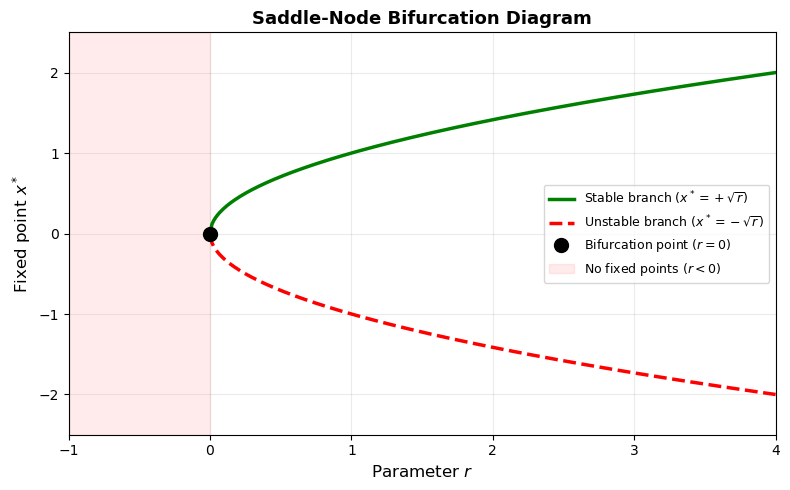


Reading the Bifurcation Diagram:
  • The x-axis is the control parameter r (think: a weight in a neural network).
  • The y-axis shows the fixed point locations x*.
  • SOLID green = stable fixed point (attractor / memory).
  • DASHED red = unstable fixed point (decision boundary).
  • At r = 0, the two branches collide — the bifurcation point.
  • For r < 0 (shaded region), no fixed points exist.



In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Saddle-Node Bifurcation Diagram: x* vs r for ẋ = r − x²
# ─────────────────────────────────────────────────────────────────

r_pos = np.linspace(0, 4, 300)

# Stable branch: x* = +√r
x_stable = np.sqrt(r_pos)
# Unstable branch: x* = -√r
x_unstable = -np.sqrt(r_pos)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_pos, x_stable, 'g-', lw=2.5, label='Stable branch ($x^* = +\\sqrt{r}$)')
ax.plot(r_pos, x_unstable, 'r--', lw=2.5, label='Unstable branch ($x^* = -\\sqrt{r}$)')

# Mark bifurcation point
ax.plot(0, 0, 'ko', ms=10, zorder=5, label='Bifurcation point $(r=0)$')

# Shaded region: no fixed points
ax.axvspan(-1, 0, alpha=0.08, color='red', label='No fixed points ($r < 0$)')

ax.set_xlabel('Parameter $r$', fontsize=12)
ax.set_ylabel('Fixed point $x^*$', fontsize=12)
ax.set_title('Saddle-Node Bifurcation Diagram', fontsize=13, fontweight='bold')
ax.set_xlim(-1, 4)
ax.set_ylim(-2.5, 2.5)
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("""
Reading the Bifurcation Diagram:
  • The x-axis is the control parameter r (think: a weight in a neural network).
  • The y-axis shows the fixed point locations x*.
  • SOLID green = stable fixed point (attractor / memory).
  • DASHED red = unstable fixed point (decision boundary).
  • At r = 0, the two branches collide — the bifurcation point.
  • For r < 0 (shaded region), no fixed points exist.
""")

## Takeaway: Saddle-Node Bifurcations 

The saddle-node bifurcation is the mathematical mechanism behind **memory creation and destruction** in neural networks.

### Binary Memory (1-bit Memory Cells)
When $r > 0$, the system has two fixed points — a stable attractor and an unstable repeller. The stable fixed point acts as a **memory**: once the system's state is pushed near it, it stays there despite small perturbations. This is exactly how:
- **LSTM gates** work: a gate's activation saturates to 0 or 1, creating a binary "remember" or "forget" decision.
- **GRU update gates** operate: the update parameter determines whether old memory persists or new input overwrites it.

### Sudden Jumps During Training
A weight update via gradient descent can push $r$ past the critical value $r = 0$, instantly creating or destroying a stored memory. This explains:
- **Sudden accuracy jumps** during training: a small weight change crosses a bifurcation point, and new attractors (learned features) appear.
- **Catastrophic forgetting**: a small parameter shift annihilates a stable fixed point, erasing a previously learned memory.

In the language of bifurcation theory: **learning is the controlled traversal of bifurcation points**.

---

# Transcritical Bifurcation

## The Model: Exchange of Stability

The **transcritical bifurcation** is fundamentally different from the saddle-node: here, fixed points never appear or disappear. Instead, they **swap stability** as a parameter crosses a critical value.

The normal form is:

$$\dot{x} = rx - x^2$$

---

## Fixed Point Analysis

Setting $\dot{x} = 0$:

$$rx - x^2 = 0 \quad \Longrightarrow \quad x(r - x) = 0$$

So we **always** have two fixed points:
- $x^*_1 = 0$
- $x^*_2 = r$

## Stability Derivation

The derivative is $f'(x) = r - 2x$:

- At $x^* = 0$: $f'(0) = r$
  - If $r < 0$: $f'(0) < 0$ → **stable**
  - If $r > 0$: $f'(0) > 0$ → **unstable**

- At $x^* = r$: $f'(r) = r - 2r = -r$
  - If $r < 0$: $f'(r) > 0$ → **unstable**
  - If $r > 0$: $f'(r) < 0$ → **stable**

| Parameter $r$ | $x^* = 0$ | $x^* = r$ |
|---|---|---|
| $r < 0$ | **Stable** ✓ | **Unstable** ✗ |
| $r = 0$ | Half-stable (both merge) | Half-stable (both merge) |
| $r > 0$ | **Unstable** ✗ | **Stable** ✓ |

The key insight: at $r = 0$, the two fixed points **collide** and **exchange stability**. Neither is created nor destroyed — they simply trade roles.

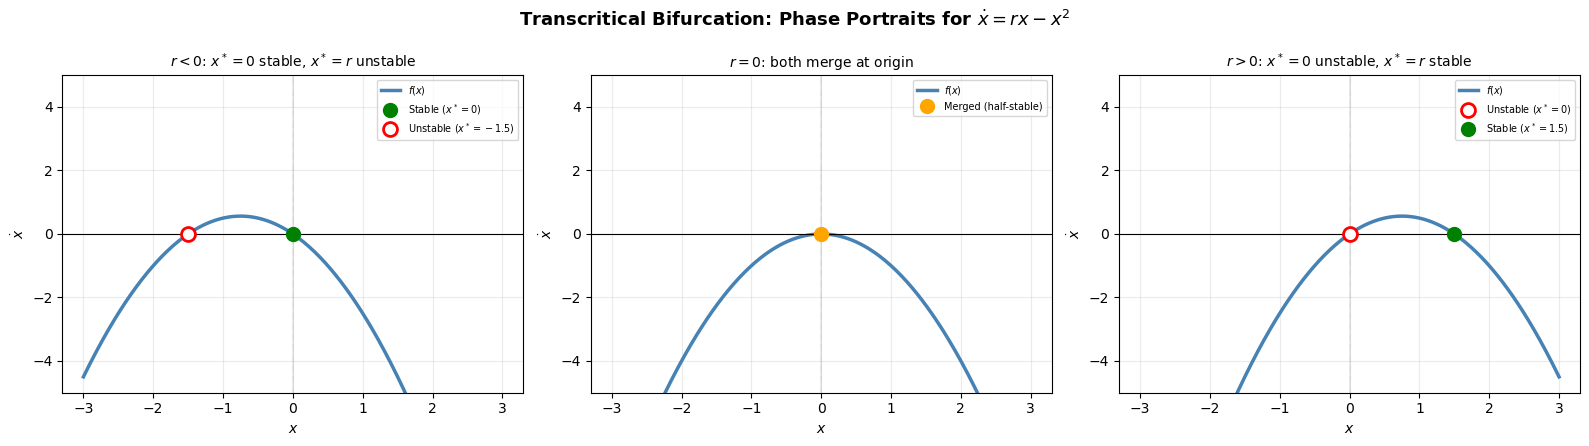


Key observations:
  • Both fixed points always exist — one at x* = 0, one at x* = r.
  • For r < 0: origin is stable, x* = r is unstable.
  • At r = 0: they collide at the origin and exchange stability.
  • For r > 0: origin becomes unstable, x* = r becomes stable.
  • No fixed points are born or destroyed — only stability is exchanged.



In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Transcritical Bifurcation: Phase Portraits for ẋ = rx − x²
# ─────────────────────────────────────────────────────────────────

def f_transcritical(x, r):
    """Vector field f(x) = rx - x² for the transcritical bifurcation."""
    return r * x - x**2

x_vals = np.linspace(-3, 3, 400)
r_values = [-1.5, 0, 1.5]
titles = [
    r'$r < 0$: $x^*=0$ stable, $x^*=r$ unstable',
    r'$r = 0$: both merge at origin',
    r'$r > 0$: $x^*=0$ unstable, $x^*=r$ stable'
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(r'Transcritical Bifurcation: Phase Portraits for $\dot{x} = rx - x^2$', fontsize=13, fontweight='bold')

for ax, r, title in zip(axes, r_values, titles):
    y_vals = f_transcritical(x_vals, r)
    ax.plot(x_vals, y_vals, 'steelblue', lw=2.5, label=r'$f(x)$')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='black', lw=0.3, ls=':')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$x$')
    ax.set_ylabel(r'$\dot{x}$')
    ax.set_ylim(-5, 5)
    ax.grid(alpha=0.25)

    # Mark fixed points
    if r < 0:
        ax.plot(0, 0, 'go', ms=10, zorder=5, label='Stable ($x^*=0$)')
        ax.plot(r, 0, 'ro', ms=10, zorder=5, markerfacecolor='white',
                markeredgewidth=2, markeredgecolor='red', label=f'Unstable ($x^*={r}$)')
    elif r == 0:
        ax.plot(0, 0, 'o', ms=10, zorder=5, color='orange', label='Merged (half-stable)')
    else:
        ax.plot(0, 0, 'ro', ms=10, zorder=5, markerfacecolor='white',
                markeredgewidth=2, markeredgecolor='red', label='Unstable ($x^*=0$)')
        ax.plot(r, 0, 'go', ms=10, zorder=5, label=f'Stable ($x^*={r}$)')

    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

print("""
Key observations:
  • Both fixed points always exist — one at x* = 0, one at x* = r.
  • For r < 0: origin is stable, x* = r is unstable.
  • At r = 0: they collide at the origin and exchange stability.
  • For r > 0: origin becomes unstable, x* = r becomes stable.
  • No fixed points are born or destroyed — only stability is exchanged.
""")

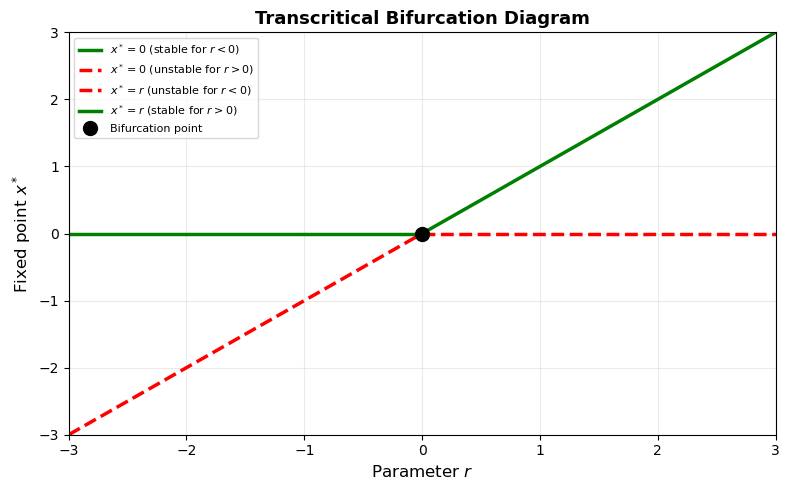


Reading the Transcritical Bifurcation Diagram:
  • SOLID green lines = stable fixed points.
  • DASHED red lines = unstable fixed points.
  • The two branches CROSS at the bifurcation point (r = 0).
  • Stability is EXCHANGED — the attractor becomes a repeller, and vice versa.



In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Transcritical Bifurcation Diagram
# ─────────────────────────────────────────────────────────────────

r_neg = np.linspace(-3, 0, 200)
r_pos = np.linspace(0, 3, 200)

fig, ax = plt.subplots(figsize=(8, 5))

# Branch x* = 0
ax.plot(r_neg, np.zeros_like(r_neg), 'g-', lw=2.5, label='$x^*=0$ (stable for $r<0$)')
ax.plot(r_pos, np.zeros_like(r_pos), 'r--', lw=2.5, label='$x^*=0$ (unstable for $r>0$)')

# Branch x* = r
ax.plot(r_neg, r_neg, 'r--', lw=2.5, label='$x^*=r$ (unstable for $r<0$)')
ax.plot(r_pos, r_pos, 'g-', lw=2.5, label='$x^*=r$ (stable for $r>0$)')

# Bifurcation point
ax.plot(0, 0, 'ko', ms=10, zorder=5, label='Bifurcation point')

ax.set_xlabel('Parameter $r$', fontsize=12)
ax.set_ylabel('Fixed point $x^*$', fontsize=12)
ax.set_title('Transcritical Bifurcation Diagram', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.25)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("""
Reading the Transcritical Bifurcation Diagram:
  • SOLID green lines = stable fixed points.
  • DASHED red lines = unstable fixed points.
  • The two branches CROSS at the bifurcation point (r = 0).
  • Stability is EXCHANGED — the attractor becomes a repeller, and vice versa.
""")

## Takeaway: Transcritical Bifurcations in AI

The transcritical bifurcation models **decision switching** — the scenario where two competing equilibria trade dominance.

### Regime Switching in Networks
Consider a neural network with two possible operating modes:
- **Mode A** (e.g., the network attends to feature A)
- **Mode B** (e.g., the network attends to feature B)

Both modes always exist as fixed points, but only one is stable at a time. A small change in a hyperparameter (learning rate, regularization strength) can push $r$ past the bifurcation point, causing the network to **switch** from Mode A to Mode B.

### Why Training is Sensitive
This explains why neural networks can be extremely sensitive to hyperparameter tuning: a small change in a single parameter can cause a **qualitative** shift in behavior — not just a gradual change, but a complete reversal of which solution is attracting.

---

# Pitchfork Bifurcation

## Symmetry Breaking

The **pitchfork bifurcation** is the signature of systems with **left-right symmetry** — i.e., the vector field satisfies $f(-x) = -f(x)$.

There are two flavors, and they have very different implications.

---

## Supercritical Pitchfork (Soft / Safe)

### Normal Form

$$\dot{x} = rx - x^3$$

Setting $\dot{x} = 0$:

$$x(r - x^2) = 0 \quad \Longrightarrow \quad x^* = 0 \quad \text{or} \quad x^* = \pm\sqrt{r}$$

The non-zero solutions exist **only when** $r > 0$.

### Stability

$f'(x) = r - 3x^2$

- At $x^* = 0$: $f'(0) = r$
  - $r < 0$: stable ✓
  - $r > 0$: unstable ✗
- At $x^* = \pm\sqrt{r}$ (when $r > 0$): $f'(\pm\sqrt{r}) = r - 3r = -2r < 0$ → **stable** ✓

| Parameter $r$ | $x^* = 0$ | $x^* = \pm\sqrt{r}$ |
|---|---|---|
| $r < 0$ | **Stable** ✓ | Don't exist |
| $r = 0$ | Loses stability | —  |
| $r > 0$ | **Unstable** ✗ | **Both stable** ✓ |

The origin smoothly "gives birth" to two symmetric stable branches. This is called **supercritical** because the new fixed points appear *after* the critical value ($r > 0$), and the transition is **safe** — the system always finds a nearby attractor.

---

## Subcritical Pitchfork (Hard / Dangerous)

### Normal Form

$$\dot{x} = rx + x^3$$

Setting $\dot{x} = 0$:

$$x(r + x^2) = 0 \quad \Longrightarrow \quad x^* = 0 \quad \text{or} \quad x^* = \pm\sqrt{-r}$$

The non-zero solutions exist **only when** $r < 0$.

### Stability

$f'(x) = r + 3x^2$

- At $x^* = 0$:
  - $r < 0$: $f'(0) = r < 0$ → **stable** ✓
  - $r > 0$: $f'(0) = r > 0$ → **unstable** ✗
- At $x^* = \pm\sqrt{-r}$ (when $r < 0$): $f'(\pm\sqrt{-r}) = r + 3(-r) = -2r > 0$ → **unstable** ✗

| Parameter $r$ | $x^* = 0$ | $x^* = \pm\sqrt{-r}$ |
|---|---|---|
| $r < 0$ | **Stable** ✓ | **Both unstable** ✗ |
| $r = 0$ | Loses stability | Disappear |
| $r > 0$ | **Unstable** ✗ | Don't exist |

This is **dangerous**: when $r$ crosses $0$, the origin becomes unstable AND the unstable branches vanish. The state has **no nearby attractor** and is flung to infinity. This is called a **catastrophic** or **hard** bifurcation.

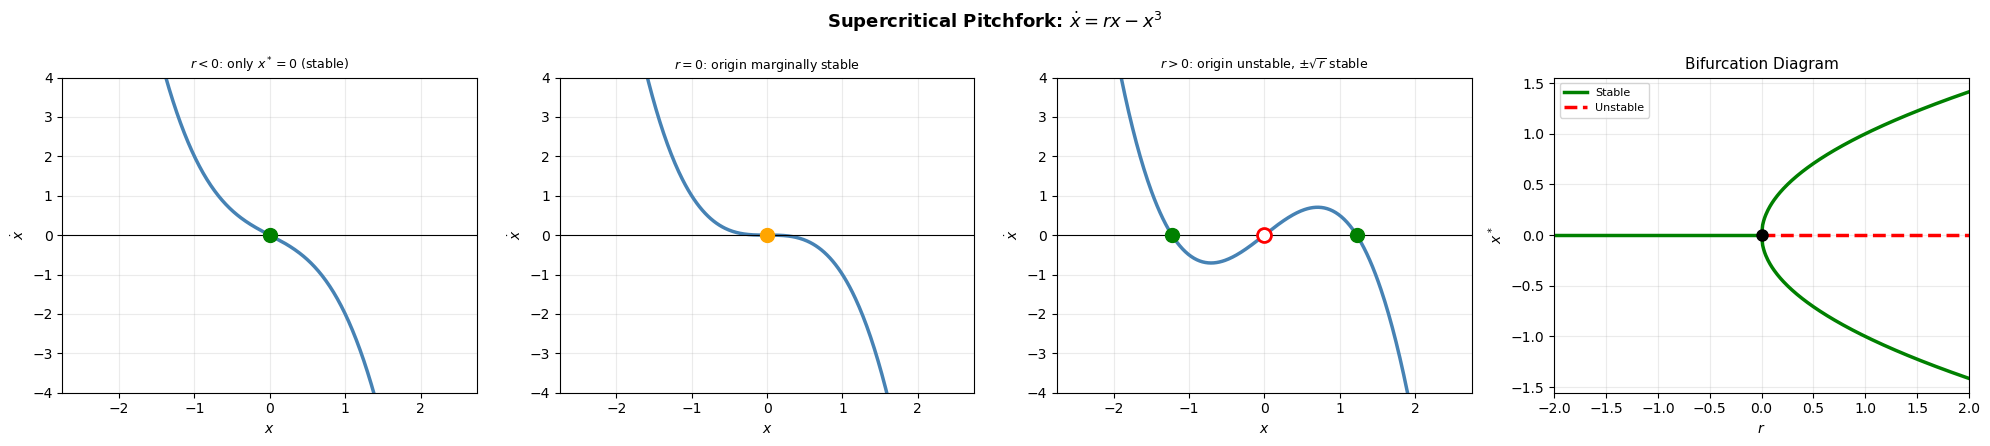


Supercritical Pitchfork:
  • For r < 0: the origin is the only fixed point, and it's stable.
  • At r = 0: the origin loses stability.
  • For r > 0: two new stable branches ±√r appear symmetrically.
  • This is a SAFE bifurcation — the system smoothly transitions to a nearby attractor.
  • The bifurcation diagram shows the characteristic 'pitchfork' shape.



In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# SUPERCRITICAL Pitchfork: Phase Portraits + Bifurcation Diagram
# ẋ = rx − x³
# ─────────────────────────────────────────────────────────────────

def f_super(x, r):
    return r * x - x**3

x_vals = np.linspace(-2.5, 2.5, 400)
r_values = [-1, 0, 1.5]
titles = [
    r'$r < 0$: only $x^*=0$ (stable)',
    r'$r = 0$: origin marginally stable',
    r'$r > 0$: origin unstable, $\pm\sqrt{r}$ stable'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle(r'Supercritical Pitchfork: $\dot{x} = rx - x^3$', fontsize=13, fontweight='bold')

# Phase portraits
for ax, r, title in zip(axes[:3], r_values, titles):
    y = f_super(x_vals, r)
    ax.plot(x_vals, y, 'steelblue', lw=2.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('$x$'); ax.set_ylabel(r'$\dot{x}$')
    ax.set_ylim(-4, 4); ax.grid(alpha=0.25)

    if r < 0:
        ax.plot(0, 0, 'go', ms=10, zorder=5)
    elif r == 0:
        ax.plot(0, 0, 'o', ms=10, zorder=5, color='orange')
    else:
        ax.plot(0, 0, 'ro', ms=10, zorder=5, markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')
        fp = np.sqrt(r)
        ax.plot(fp, 0, 'go', ms=10, zorder=5)
        ax.plot(-fp, 0, 'go', ms=10, zorder=5)

# Bifurcation diagram (4th panel)
ax_bif = axes[3]
r_neg = np.linspace(-2, 0, 200)
r_pos = np.linspace(0, 2, 200)

ax_bif.plot(r_neg, np.zeros_like(r_neg), 'g-', lw=2.5, label='Stable')
ax_bif.plot(r_pos, np.zeros_like(r_pos), 'r--', lw=2.5, label='Unstable')
ax_bif.plot(r_pos, np.sqrt(r_pos), 'g-', lw=2.5)
ax_bif.plot(r_pos, -np.sqrt(r_pos), 'g-', lw=2.5)
ax_bif.plot(0, 0, 'ko', ms=8, zorder=5)
ax_bif.set_title('Bifurcation Diagram', fontsize=11)
ax_bif.set_xlabel('$r$'); ax_bif.set_ylabel('$x^*$')
ax_bif.legend(fontsize=8); ax_bif.grid(alpha=0.25)
ax_bif.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

print("""
Supercritical Pitchfork:
  • For r < 0: the origin is the only fixed point, and it's stable.
  • At r = 0: the origin loses stability.
  • For r > 0: two new stable branches ±√r appear symmetrically.
  • This is a SAFE bifurcation — the system smoothly transitions to a nearby attractor.
  • The bifurcation diagram shows the characteristic 'pitchfork' shape.
""")

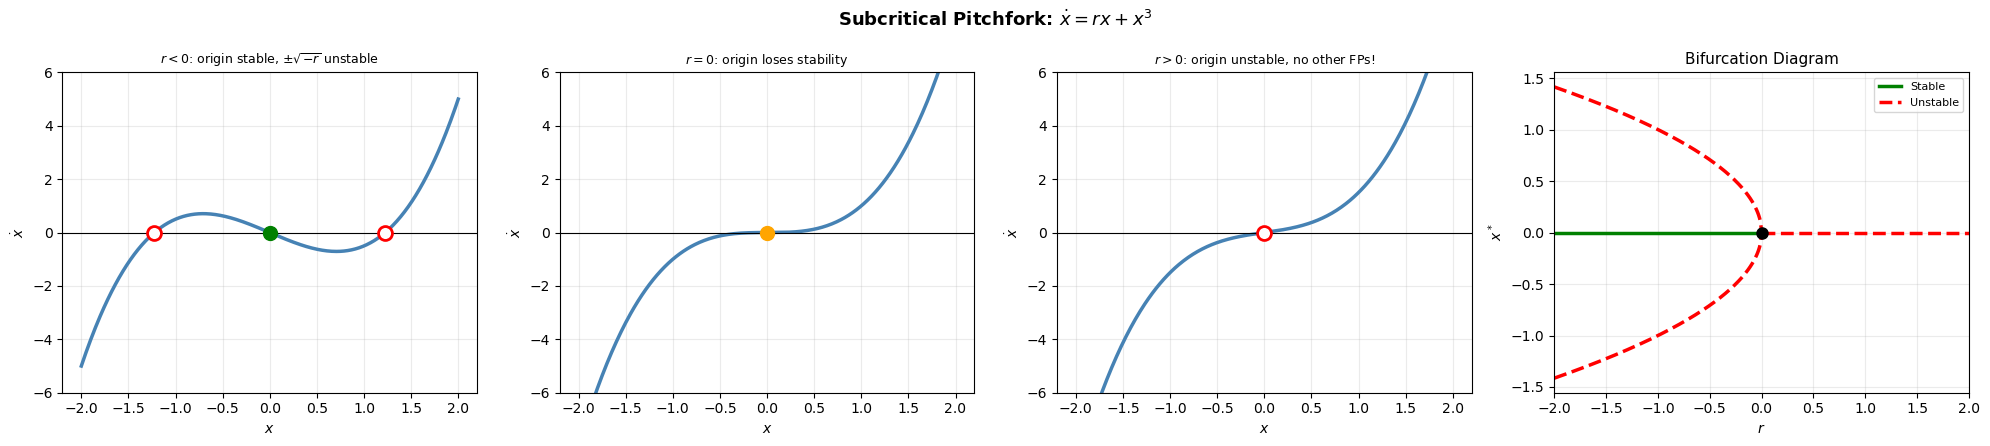


Subcritical Pitchfork — THE DANGEROUS ONE:
  • For r < 0: the origin is stable, flanked by two UNSTABLE branches.
  • At r = 0: the origin loses stability AND the unstable branches vanish.
  • For r > 0: the origin is unstable, and there are NO nearby attractors.
  • Any perturbation sends the state to INFINITY — a catastrophic jump.
  • Compare with the supercritical case, which has a 'soft landing'.



In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# SUBCRITICAL Pitchfork: Phase Portraits + Bifurcation Diagram
# ẋ = rx + x³
# ─────────────────────────────────────────────────────────────────

def f_sub(x, r):
    return r * x + x**3

x_vals = np.linspace(-2, 2, 400)
r_values = [-1.5, 0, 0.5]
titles = [
    r'$r < 0$: origin stable, $\pm\sqrt{-r}$ unstable',
    r'$r = 0$: origin loses stability',
    r'$r > 0$: origin unstable, no other FPs!'
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle(r'Subcritical Pitchfork: $\dot{x} = rx + x^3$', fontsize=13, fontweight='bold')

for ax, r, title in zip(axes[:3], r_values, titles):
    y = f_sub(x_vals, r)
    ax.plot(x_vals, y, 'steelblue', lw=2.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('$x$'); ax.set_ylabel(r'$\dot{x}$')
    ax.set_ylim(-6, 6); ax.grid(alpha=0.25)

    if r < 0:
        ax.plot(0, 0, 'go', ms=10, zorder=5)
        fp = np.sqrt(-r)
        ax.plot(fp, 0, 'ro', ms=10, zorder=5, markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')
        ax.plot(-fp, 0, 'ro', ms=10, zorder=5, markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')
    elif r == 0:
        ax.plot(0, 0, 'o', ms=10, zorder=5, color='orange')
    else:
        ax.plot(0, 0, 'ro', ms=10, zorder=5, markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')

# Bifurcation diagram (4th panel)
ax_bif = axes[3]
r_neg = np.linspace(-2, 0, 200)
r_pos = np.linspace(0, 2, 200)

ax_bif.plot(r_neg, np.zeros_like(r_neg), 'g-', lw=2.5, label='Stable')
ax_bif.plot(r_pos, np.zeros_like(r_pos), 'r--', lw=2.5, label='Unstable')
ax_bif.plot(r_neg, np.sqrt(-r_neg), 'r--', lw=2.5)
ax_bif.plot(r_neg, -np.sqrt(-r_neg), 'r--', lw=2.5)
ax_bif.plot(0, 0, 'ko', ms=8, zorder=5)
ax_bif.set_title('Bifurcation Diagram', fontsize=11)
ax_bif.set_xlabel('$r$'); ax_bif.set_ylabel('$x^*$')
ax_bif.legend(fontsize=8); ax_bif.grid(alpha=0.25)
ax_bif.set_xlim(-2, 2)

plt.tight_layout()
plt.show()

print("""
Subcritical Pitchfork — THE DANGEROUS ONE:
  • For r < 0: the origin is stable, flanked by two UNSTABLE branches.
  • At r = 0: the origin loses stability AND the unstable branches vanish.
  • For r > 0: the origin is unstable, and there are NO nearby attractors.
  • Any perturbation sends the state to INFINITY — a catastrophic jump.
  • Compare with the supercritical case, which has a 'soft landing'.
""")

## Takeaway: Pitchfork Bifurcations in AI

### The Tanh Connection

Recall from Flows_on the line notebook the recurrent Tanh neuron:

$$\dot{x} = -x + \tanh(wx)$$

When we expand $\tanh(wx) \approx wx - \frac{(wx)^3}{3}$ for small $x$, this becomes:

$$\dot{x} \approx (w-1)x - \frac{w^3}{3}x^3$$

Setting $r = w - 1$, this is precisely the **supercritical pitchfork** form $\dot{x} = rx - cx^3$ (with $c = w^3/3 > 0$).

- When $w < 1$ ($r < 0$): only $x^* = 0$ is stable — the neuron is **monostable** (always off).
- When $w > 1$ ($r > 0$): the origin loses stability and two symmetric attractors appear — the neuron becomes **bistable** (binary memory).

**The weight $w = 1$ is a pitchfork bifurcation point.** Crossing it creates two new memories from nothing.

### Symmetry Breaking in Modern AI

- **Weight initialization**: Random breaking of symmetry in neural networks is essential for learning. If all neurons start identical, gradient descent preserves the symmetry and no learning occurs. Pitchfork theory explains *why*: the symmetric fixed point is unstable when parameters exceed the bifurcation threshold.

- **Mode collapse in GANs**: The subcritical pitchfork explains catastrophic mode collapse — the generator's stable operating point suddenly disappears, and the model jumps to a degenerate solution.

- **SSMs and eigenvalue placement**: In state-space models like S4/Mamba, the system matrix $A$ determines the dynamics. Crossing an eigenvalue threshold triggers a pitchfork-like bifurcation that qualitatively changes the model's long-range memory capabilities.

---

# The Grand Bridge: Bifurcations as "Learning"

The three bifurcation types we've studied form a complete vocabulary for understanding **structural change** in dynamical systems — and therefore in AI:

| Concept | Dynamical Systems | AI / Deep Learning |
|---|---|---|
| **Parameter** | $r$ in $\dot{x} = f(x; r)$ | Weights $w$, learning rate $\eta$, etc. |
| **Fixed point** | Where $\dot{x} = 0$ | A stable representation / learned feature |
| **Saddle-Node** | FPs created/destroyed | Memory born / catastrophic forgetting |
| **Transcritical** | FPs swap stability | Dominant mode switches |
| **Pitchfork** | FP splits into branches | Symmetry breaking → binary decisions |

---

## Three Key Insights

### 1. Learning = Parameter Change
Every gradient-descent step updates $w$, which shifts the dynamical-system parameters. Training a neural network is literally **traversing parameter space**, and the path through that space may cross bifurcation points.

### 2. Bifurcation = Phase Transition
At critical parameter values, the "topology" of the loss landscape changes: fixed points are born, die, or swap stability. This is why training curves often show **sudden jumps** in accuracy — the network has crossed a bifurcation point, and a new attractor (a better solution) has appeared.

### 3. Practical Implications
- **Sudden accuracy jumps**: A small weight change crosses a saddle-node bifurcation, creating new attractors.
- **Mode collapse in GANs**: A subcritical pitchfork — the stable mode disappears catastrophically.
- **Catastrophic forgetting**: A saddle-node bifurcation destroys a learned memory.
- **Learning rate sensitivity**: A transcritical bifurcation — small parameter changes cause qualitative regime switches.
- In a Transformer, the weights are fixed after training. In a Selective SSM, the model essentially "bifurcates" its own state transition matrix $A$ depending on what it sees. If it sees a "Start of Code" token, it might undergo a bifurcation to create stable attractors for Python syntax, then collapse them when the code block ends.

Bifurcation theory doesn't just *describe* these phenomena — it **predicts** them. By understanding the bifurcation structure of a network's dynamics, we can anticipate when training will be smooth and when it will be turbulent.

---
